21.00000000000001
Empirical slopes (using last 5 points):
Full Rayleigh Quotient: 1.95
Truncated (k=5): 0.76
Truncated (k=10): 0.64
Truncated (k=15): 0.25
Truncated (k=18): 1.36

Energy captured in v1[:k]:
k=5: 0.346
k=10: 0.570
k=15: 0.798
k=18: 0.987


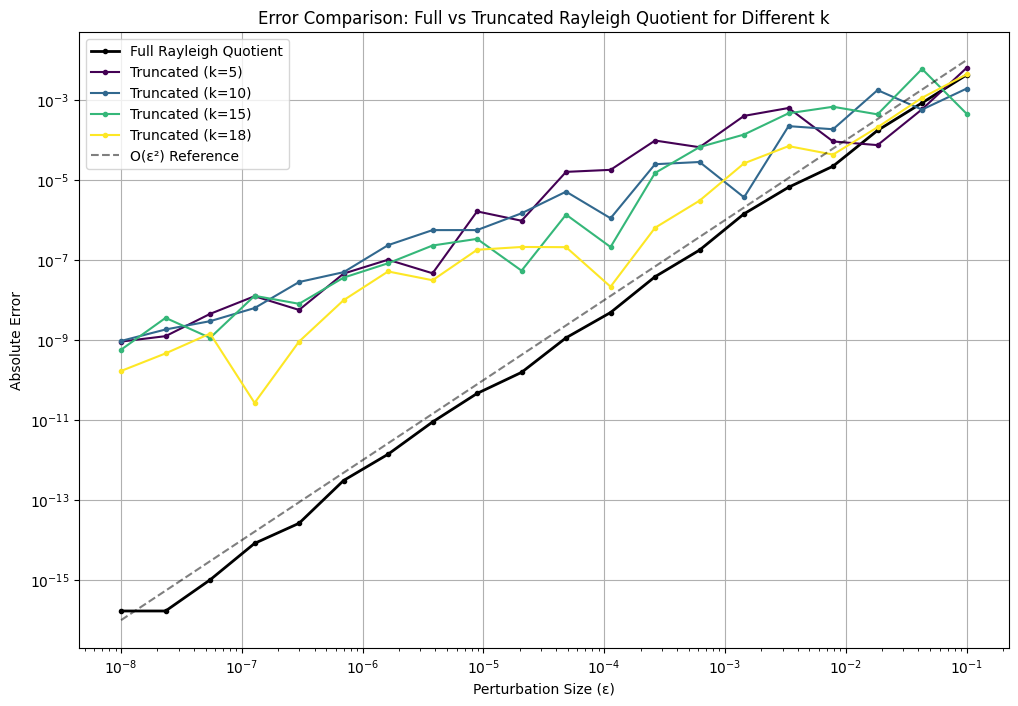

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Generate a random symmetric matrix
def generate_matrix(n):
    S = np.linspace(1,n+1, n)
    V = np.random.rand(n, n)
    V, _ = np.linalg.qr(V)
    A = V @ np.diag(S) @ V.T
    return A #(A + A.T) / 2

# Standard Rayleigh quotient
def rayleigh_quotient(A, x):
    return (x.T @ A @ x) / (x.T @ x)

# Truncated Rayleigh quotient
def truncated_quotient(A, x, k):
    xk = x[:k]
    return (xk.T @ A[0:k,:] @ x) / (xk.T @ xk)

# Test parameters
n = 20  # matrix size
k_values = [5, 10, 15, 18]  # different truncation sizes
A = generate_matrix(n)
eigenvals, eigenvects = eigh(A)
v1 = eigenvects[:,-1]  # true eigenvector
lambda1 = eigenvals[-1]  # true eigenvalue
print(lambda1)

# Generate perturbations
eps_range = np.logspace(-8, -1, 20)
errors = {k: [] for k in k_values}
rq_errors = []

# Color map for different k values
colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))

for eps in eps_range:
    # Generate random perturbation orthogonal to v1
    h = np.random.randn(n)
    h = h - (h.T @ v1) * v1  # make orthogonal to v1
    h = h / np.linalg.norm(h)
    
    x = v1 + eps * h
    x = x / np.linalg.norm(x)
    
    # Compute errors for full Rayleigh quotient
    rq_error = abs(rayleigh_quotient(A, x) - lambda1) / abs(lambda1)
    rq_errors.append(rq_error)
    
    # Compute errors for each k
    for k in k_values:
        trq_error = abs(truncated_quotient(A, x, k) - lambda1) / abs(lambda1)
        errors[k].append(trq_error)

# Plot results
plt.figure(figsize=(12, 8))

# Plot full Rayleigh quotient
plt.loglog(eps_range, rq_errors, 'k.-', label='Full Rayleigh Quotient', linewidth=2)

# Plot truncated quotients for different k
for k, color in zip(k_values, colors):
    plt.loglog(eps_range, errors[k], '.-', color=color, label=f'Truncated (k={k})')

# Plot reference line
plt.loglog(eps_range, eps_range**2, 'k--', label='O(ε²) Reference', alpha=0.5)

plt.grid(True)
plt.xlabel('Perturbation Size (ε)')
plt.ylabel('Absolute Error')
plt.legend()
plt.title('Error Comparison: Full vs Truncated Rayleigh Quotient for Different k')

# Compute and print slopes
print("Empirical slopes (using last 5 points):")
print(f"Full Rayleigh Quotient: {np.polyfit(np.log(eps_range[-5:]), np.log(rq_errors[-5:]), 1)[0]:.2f}")
for k in k_values:
    slope = np.polyfit(np.log(eps_range[-5:]), np.log(errors[k][-5:]), 1)[0]
    print(f"Truncated (k={k}): {slope:.2f}")

# Add information about v1's energy distribution
energy_distribution = [np.linalg.norm(v1[:k])**2 for k in k_values]
print("\nEnergy captured in v1[:k]:")
for k, energy in zip(k_values, energy_distribution):
    print(f"k={k}: {energy:.3f}")

plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
Q = np.random.rand(2,2)
Q, _ = np.linalg.qr(Q)
S = np.array([2,0])
A = Q @ np.diag(S) @ Q.T 

a = np.linspace(1,1e-6,100)#np.random.rand(1)
a = 0.1
v = np.array([a, np.sqrt(1-a**2)])

tr = np.dot(v[:1], A[:1,:]@v) / np.dot(v[:1], v[:1])
# plt.plot(a,tr)
A

array([[0.41497189, 0.81101302],
       [0.81101302, 1.58502811]])

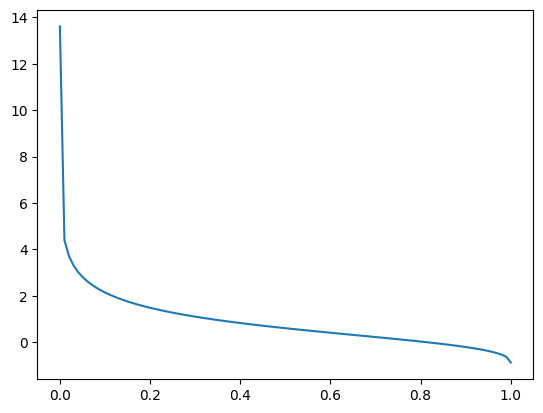

In [24]:
import numpy as np

# Create array of a values
a_values = np.linspace(1, 1e-6, 100)

# Create array of v vectors: shape will be (100, 2)
v_vectors = np.column_stack([
    a_values,
    np.sqrt(1 - a_values**2)
])

# Compute all numerators: v[:, :1] @ A[:1, :] @ v.T
# Shape: (100,1) @ (1,2) @ (2,100) = (100,)
numerators = (v_vectors[:, :1] @ A[:1, :] @ v_vectors.T).diagonal()

# Compute all denominators: v[:, :1] @ v[:, :1].T
# Shape: (100,1) @ (1,100) = (100,100), then take diagonal
denominators = (v_vectors[:, :1] @ v_vectors[:, :1].T).diagonal()

# Final result
tr_values = numerators / denominators
plt.plot(a_values,np.log(tr_values))

In [16]:
np.matmul(v[:1,:], A[:1,:]@v).shape

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 100)

In [32]:
n = 5
k = 3
A = np.eye(n) * np.arange(1,n+1)
B = np.random.rand(k,k)
B /= np.linalg.norm(B, 'fro')
B *= 3
A[:k, n-k:] = B
A = A+A.T
print(A)

np.linalg.eigh(A)

[[ 2.          0.          1.60041562  0.56795298  0.19655231]
 [ 0.          4.          0.40709132  0.76281287  1.46097123]
 [ 1.60041562  0.40709132  3.07452303  0.01241648  0.91219272]
 [ 0.56795298  0.76281287  0.01241648  8.          0.        ]
 [ 0.19655231  1.46097123  0.91219272  0.         10.        ]]


EighResult(eigenvalues=array([ 0.78752209,  3.54683567,  4.07700023,  8.15955093, 10.50361411]), eigenvectors=array([[ 0.80256265, -0.14514431, -0.56882586, -0.09107226, -0.05449141],
       [ 0.07805863,  0.95534971, -0.08940782, -0.13643926, -0.23367576],
       [-0.58653312, -0.06393225, -0.79455751, -0.01910205, -0.14214443],
       [-0.07044449, -0.14495852,  0.1022517 , -0.97799222, -0.08426393],
       [ 0.02857475, -0.2028294 ,  0.16329831,  0.12750098, -0.95661951]]))

In [45]:
n = 5
k = 2
np.random.seed(42)
Q = np.random.rand(n,n)
Q[:,0][:k] = 0
Q, _ = np.linalg.qr(Q)
Q

array([[ 0.        , -0.6903709 , -0.10594638,  0.67983045,  0.22359325],
       [-0.        , -0.04217801,  0.96523693,  0.02309462,  0.25691502],
       [-0.03220951, -0.69841344, -0.01586198, -0.71473441,  0.00918359],
       [-0.2869815 , -0.16839175,  0.22852138,  0.16083521, -0.90066412],
       [-0.95739447,  0.07397251, -0.06796624, -0.02416505,  0.26966747]])

In [46]:
S = np.linspace(1,n+1,n)[::-1]
S[0] = 1e5
A = Q @ np.diag(S) @ Q.T
A

array([[ 3.39306830e+00, -1.26838605e-01,  1.20494469e+00,
         5.12096163e-01, -1.94039979e-01],
       [-1.26838605e-01,  3.33654372e+00,  5.15567490e-02,
         5.82720340e-01, -1.76406468e-01],
       [ 1.20494469e+00,  5.15567490e-02,  1.07212571e+02,
         9.24632338e+02,  3.08352022e+03],
       [ 5.12096163e-01,  5.82720340e-01,  9.24632338e+02,
         8.23702513e+03,  2.74750851e+04],
       [-1.94039979e-01, -1.76406468e-01,  3.08352022e+03,
         2.74750851e+04,  9.16605327e+04]])

In [48]:
np.linalg.svd(A[:k], full_matrices=False)

SVDResult(U=array([[-0.97123385,  0.2381277 ],
       [ 0.2381277 ,  0.97123385]]), S=array([3.6596828 , 3.37778927]), Vh=array([[-0.90873083,  0.25076311, -0.3164225 , -0.09798753,  0.04001738],
       [ 0.20273426,  0.95043242,  0.09977069,  0.20365451, -0.06440255]]))

In [55]:
import numpy as np

def create_controlled_psd(n, gamma, eigenvalues=None):
    """
    Create a PSD matrix with controllable diagonal dominance via eigenvector spread.
    
    Parameters:
    n: dimension of the matrix
    gamma: spread parameter in [0, pi/4]
        0 = maximum diagonal dominance (eigenvectors = standard basis)
        pi/4 = minimum diagonal dominance (maximally mixed eigenvectors)
    eigenvalues: optional array of n positive eigenvalues
        if None, will use [1, 2, ..., n]
    
    Returns:
    A: the PSD matrix
    V: the matrix of eigenvectors
    s: the eigenvalues used
    """
    # Set default eigenvalues if none provided
    if eigenvalues is None:
        S = np.arange(1, n+1, dtype=float)[::-1]
    else:
        S = np.array(eigenvalues, dtype=float)
        S = np.sort(S)
        assert len(S) == n and np.all(S > 0)
    
    # Start with identity matrix (canonical basis vectors)
    V = np.eye(n)
    
    # Apply controlled rotations to mix the vectors
    for i in range(n-1):
        for j in range(i+1, n):
            # Create Givens rotation matrix
            c = np.cos(gamma)
            s = np.sin(gamma)
            G = np.eye(n)
            G[i,i] = c
            G[i,j] = -s
            G[j,i] = s
            G[j,j] = c
            
            # Apply rotation
            V = V @ G
            print(V)
    
    # Ensure V is exactly orthogonal (correct for numerical errors)
    V, _ = np.linalg.qr(V)
    
    # Construct PSD matrix
    A = V @ np.diag(S) @ V.T
    
    # Ensure symmetry (correct for numerical errors)
    A = (A + A.T) / 2
    
    return A, V, s

def compute_diagonal_dominance(A):
    """
    Compute measure of diagonal dominance as min_i |a_ii| / sum_j!=i |a_ij|
    Returns: minimum ratio across all rows
    """
    n = A.shape[0]
    ratios = np.zeros(n)
    for i in range(n):
        diag = np.abs(A[i,i])
        off_diag_sum = np.sum(np.abs(A[i,:])) - diag
        ratios[i] = diag / off_diag_sum if off_diag_sum != 0 else np.inf
    return np.min(ratios)

# Example usage:
if __name__ == "__main__":
    n = 4
    gammas = [0, np.pi/16, np.pi/8]
    
    print("Diagonal dominance for different gamma values:")
    for gamma in gammas:
        A, V, s = create_controlled_psd(n, gamma, eigenvalues=np.linspace(1,2**n,n))
        dom = compute_diagonal_dominance(A)
        print(f"\ngamma = {gamma:.3f}")
        print(f"Diagonal dominance ratio: {dom:.3f}")
        print("Matrix A:")
        print(A.round(3))

Diagonal dominance for different gamma values:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

gamma = 0.000
Diagonal dominance ratio: inf
Matrix A:
[[ 1.  0.  0.  0.]
 [ 0.  6.  0.  0.]
 [ 0.  0. 11.  0.]
 [ 0.  0.  0. 16.]]
[[ 0.98078528 -0.19509032  0.          0.        ]
 [ 0.19509032  0.98078528  0.          0.        ]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]]
[[ 0.96193977 -0.19509032 -0.19134172  0.        ]
 [ 0.19134172  0.98078528 -0.03806023  0.        ]
 [ 0.19509032  0.          0.98078528  0.        ]
 [ 0.          0.          0.          1.        ]]
[[ 0.94345636 -0.19509032 -0.19134172 -0.1876

In [6]:
import numpy as np
A = np.array([
    [0.1, 2.0, 3.0],
    [2.0, 0.4, 2.0],
    [3.0, 2.0, 10.5],
])
np.linalg.svd(A[:2,:], full_matrices=False)

SVDResult(U=array([[-0.81466016, -0.57993863],
       [-0.57993863,  0.81466016]]), S=array([4.24183284, 1.78237318]), Vh=array([[-0.29264314, -0.43879517, -0.84959919],
       [ 0.8815923 , -0.46792288, -0.06199351]]))

In [5]:
np.linalg.svd(A[:,:], full_matrices=False)

SVDResult(U=array([[-0.2758234 ,  0.78012525, -0.561539  ],
       [-0.2122043 , -0.61920808, -0.75600971],
       [-0.93749175, -0.08936417,  0.33633801]]), S=array([11.83534913,  1.8311113 ,  0.99576217]), Vh=array([[-0.2758234 , -0.2122043 , -0.93749175],
       [-0.78012525,  0.61920808,  0.08936417],
       [-0.561539  , -0.75600971,  0.33633801]]))

In [7]:
np.linalg.svd(A[:2,:2], full_matrices=False)

SVDResult(U=array([[-0.68015074, -0.73307228],
       [-0.73307228,  0.68015074]]), S=array([2.25561711, 1.75561711]), Vh=array([[-0.68015074, -0.73307228],
       [ 0.73307228, -0.68015074]]))

In [15]:
import numpy as np
from numpy.linalg import svd, qr, norm
np.set_printoptions(precision=4, suppress=True)

# Set random seed for reproducibility
np.random.seed(42)

# Define dimensions
n = 100  # large dimension
m = 5    # low rank
k = 10   # size of A22 block

# Generate random orthogonal V and diagonal S
V_full, _ = np.linalg.qr(np.random.randn(n, m))
V = V_full[:, :m]  # Take only m columns
S = np.diag(np.sort(np.random.rand(m))[::-1])  # Sorted singular values

# Generate random blocks
A12 = np.random.randn(n, k)
A21 = np.random.randn(k, n)
A22 = np.random.randn(k, k)

# Construct original matrix M
B = V @ S @ V.T
M = np.block([[B, A12],
              [A21, A22]])

print("Step 1: Verify dimensions")
print(f"M shape: {M.shape} (should be {n+k}×{n+k})")
print(f"rank(B): {np.linalg.matrix_rank(B)} (should be ≤ {m})")

print("\nStep 2: Orthogonalization Process")
# Orthogonalize A12 against V
A12_proj = A12 - V @ (V.T @ A12)
Q2, R2 = qr(A12_proj)
Q2 = Q2[:, :k]  # Keep only k columns

# Verify orthogonality
print("V'V =")
print(V.T @ V)
print("\nV'Q2 =")
print(np.abs(V.T @ Q2).max())
print("\nQ2'Q2 =")
print(Q2.T @ Q2)

print("\nStep 3: Construct P = [V Q2 I_k]")
P = np.block([[V, Q2, np.zeros((n, k))],
              [np.zeros((k, m)), np.zeros((k, k)), np.eye(k)]])

print(f"P shape: {P.shape}")
print("P'P =")
print(np.abs(P.T @ P - np.eye(m + k + k)).max())

print("\nStep 4: Compute M' = P'MP")
# Compute blocks directly as derived
M11 = S
M12 = V.T @ A12
M13 = np.zeros((m, k))
M21 = np.zeros((k, m))
M22 = R2
M23 = np.zeros((k, k))
M31 = A21 @ V
M32 = A21 @ Q2
M33 = A22

# Construct M' from blocks
M_prime_derived = np.block([[M11, M12, M13],
                           [M21, M22, M23],
                           [M31, M32, M33]])

# Compute M' directly
M_prime_direct = P.T @ M @ P

print("Maximum difference between derived and direct M':")
print(np.abs(M_prime_derived - M_prime_direct).max())

print("\nStep 5: Verify SVD equivalence")
# Compute SVD of reduced matrix
U_prime, S_prime, Vh_prime = svd(M_prime_direct)

# Transform back
U_full = P @ U_prime
Vh_full = (P @ Vh_prime.T).T

# Verify reconstruction
M_reconstructed = U_full @ np.diag(S_prime) @ Vh_full
print("Maximum difference between original M and reconstructed M:")
print(np.abs(M - M_reconstructed).max())

# Verify singular values
S_original = svd(M, compute_uv=False)
print("\nFirst few singular values comparison:")
print("Original M:", S_original[:5])
print("From M':", S_prime[:5])
print("Maximum difference in singular values:")
print(np.abs(S_original - S_prime).max())

Step 1: Verify dimensions
M shape: (110, 110) (should be 110×110)
rank(B): 5 (should be ≤ 5)

Step 2: Orthogonalization Process
V'V =
[[ 1.  0.  0. -0.  0.]
 [ 0.  1. -0.  0. -0.]
 [ 0. -0.  1.  0.  0.]
 [-0.  0.  0.  1.  0.]
 [ 0. -0.  0.  0.  1.]]

V'Q2 =
1.2950472998505387e-16

Q2'Q2 =
[[ 1.  0. -0.  0.  0. -0.  0.  0.  0. -0.]
 [ 0.  1. -0. -0.  0. -0. -0. -0.  0.  0.]
 [-0. -0.  1.  0. -0. -0.  0.  0.  0.  0.]
 [ 0. -0.  0.  1.  0.  0. -0.  0.  0.  0.]
 [ 0.  0. -0.  0.  1. -0.  0.  0.  0.  0.]
 [-0. -0. -0.  0. -0.  1.  0.  0. -0.  0.]
 [ 0. -0.  0. -0.  0.  0.  1. -0. -0.  0.]
 [ 0. -0.  0.  0.  0.  0. -0.  1. -0. -0.]
 [ 0.  0.  0.  0.  0. -0. -0. -0.  1.  0.]
 [-0.  0.  0.  0.  0.  0.  0. -0.  0.  1.]]

Step 3: Construct P = [V Q2 I_k]
P shape: (110, 25)
P'P =
6.661338147750939e-16

Step 4: Compute M' = P'MP
Maximum difference between derived and direct M':
10.501957102547305

Step 5: Verify SVD equivalence
Maximum difference between original M and reconstructed M:
3.029608894

ValueError: operands could not be broadcast together with shapes (110,) (25,) 

In [16]:
S_original, S_prime

(array([13.5038, 13.274 , 12.8459, 12.1671, 11.8158, 11.5983, 11.1914,
        10.8192, 10.4928,  9.9174,  9.6289,  9.373 ,  9.1711,  8.8675,
         8.0179,  7.9762,  7.755 ,  7.3277,  6.6572,  5.7291,  0.9188,
         0.5869,  0.5444,  0.5219,  0.3229,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
      

In [23]:
import numpy as np
from scipy.sparse.linalg import LinearOperator, svds
import time

# Generate sample data
n = 100  # Large dimension
m = 10     # Low rank
k = 50     # Block size

# Create random orthonormal V (n x m)
V_full = np.random.randn(n, m)
V, _ = np.linalg.qr(V_full)

# Create singular values
S = np.diag(np.linspace(10, 1, m))

# Create random blocks
A12 = np.random.randn(n, k) / np.sqrt(n)
A22 = np.random.randn(k, k) / np.sqrt(k)

def make_operators(V, S, A12, A22):
    n, m = V.shape
    k = A22.shape[0]
    shape = (n+k, n+k)
    
    def matvec(x):
        x1, x2 = x[:n], x[n:]
        t1 = V.T @ x1
        t2 = S @ t1
        t3 = V @ t2
        return np.concatenate([
            t3 + A12 @ x2,
            A12.T @ x1 + A22 @ x2
        ])
    
    def rmatvec(x):
        x1, x2 = x[:n], x[n:]
        t1 = V.T @ x1
        t2 = S.T @ t1
        t3 = V @ t2
        return np.concatenate([
            t3 + A12 @ x2,
            A12.T @ x1 + A22.T @ x2
        ])
    
    return LinearOperator(shape, matvec=matvec, rmatvec=rmatvec)

# Create full matrix for comparison
M_full = np.block([
    [V @ S @ V.T, A12],
    [A12.T, A22]
])

print(f"Matrix size: {M_full.shape}")

# Time full SVD
t0 = time.time()
try:
    u_full, s_full, vt_full = np.linalg.svd(M_full, full_matrices=False)
    t_full = time.time() - t0
    print(f"\nFull SVD time: {t_full:.2f} seconds")
    print("Largest singular values (full):", s_full[:6])
except MemoryError:
    print("\nFull SVD failed due to memory error")
    s_full = None

# Time sparse SVD
def make_operators(V, S, A12, A22):
    n, m = V.shape
    k = A22.shape[0]
    shape = (n+k, n+k)
    
    def matvec(x):
        x1, x2 = x[:n], x[n:]
        t1 = V.T @ x1
        t2 = S @ t1
        t3 = V @ t2
        return np.concatenate([
            t3 + A12 @ x2,
            A12.T @ x1 + A22 @ x2
        ])
    
    def rmatvec(x):
        x1, x2 = x[:n], x[n:]
        t1 = V.T @ x1
        t2 = S.T @ t1
        t3 = V @ t2
        return np.concatenate([
            t3 + A12 @ x2,
            A12.T @ x1 + A22.T @ x2
        ])
    
    return LinearOperator(shape, matvec=matvec, rmatvec=rmatvec)

M_op = make_operators(V, S, A12, A22)
t0 = time.time()
u_sparse, s_sparse, vt_sparse = svds(M_op, k=6, which='LM')
t_sparse = time.time() - t0
print(f"\nSparse SVD time: {t_sparse:.2f} seconds")
print("Largest singular values (sparse):", np.flip(s_sparse))  # flip because svds returns ascending order

# Compare results if full SVD succeeded
if s_full is not None:
    rel_error = np.abs(s_full[:6] - np.flip(s_sparse)) / s_full[:6]
    print(f"\nRelative errors: {rel_error}")
    print(f"Max relative error: {np.max(rel_error):.2e}")
    print(f"Speed ratio (full/sparse): {t_full/t_sparse:.1f}x")

# Check memory usage
import psutil
process = psutil.Process()
print(f"\nMemory usage: {process.memory_info().rss / 1024 / 1024:.1f} MB")

Matrix size: (150, 150)

Full SVD time: 0.01 seconds
Largest singular values (full): [10.0569  9.0653  8.087   7.1027  6.0747  5.1032]

Sparse SVD time: 0.00 seconds
Largest singular values (sparse): [10.0569  9.0653  8.087   7.1027  6.0747  5.1032]

Relative errors: [0. 0. 0. 0. 0. 0.]
Max relative error: 1.32e-15
Speed ratio (full/sparse): 2.5x

Memory usage: 153.5 MB


In [24]:
import numpy as np
from scipy.sparse.linalg import LinearOperator, svds
from scipy.linalg import eigh

# Parameters
n = 1000  # Total matrix size
k = 50     # Block size
num_windows = n // k  # Number of windows we'll process

# Simulate streaming matrix A by generating blocks
# (In practice, these would come from your data source)
A = np.random.randn(n, n)
A = 0.5 * (A + A.T)  # Make symmetric

# Initialize storage for current window
current_V11 = None
current_S11 = None
previous_V11 = None
previous_S11 = None

for w in range(1, num_windows + 1):
    print(f"\nProcessing window {w}")
    
    # Get new block B (k rows)
    start_row = (w-1)*k
    end_row = w*k
    B = A[start_row:end_row, :]
    
    if w == 1:
        # First window - split B into A11 (k x k) and A12
        A11 = B[:, :k]
        A12 = B[:, k:]
        
        # Compute eigendecomposition of A11 directly
        S11, V11 = eigh(A11)
        # Sort in descending order
        idx = np.argsort(np.abs(S11))[::-1]
        S11 = S11[idx]
        V11 = V11[:, idx]
        
    else:
        # Compute first k columns of previous A12 using previous V11, S11
        prev_size = (w-1)*k
        computed_cols = np.zeros((prev_size, k))
        
        # Reconstruct using previous eigendecomposition
        for i in range(k):
            computed_cols[:, i] = previous_V11 @ (previous_S11[:, None] * previous_V11[:, i])
            
        # Form new A11 combining previous decomposition with new block
        new_block = B[:, :prev_size]  # First prev_size columns of new block
        A11_top = np.concatenate([
            previous_V11 @ np.diag(previous_S11) @ previous_V11.T,
            computed_cols
        ], axis=1)
        A11_bottom = np.concatenate([
            new_block,
            B[:, prev_size:prev_size+k]
        ], axis=1)
        A11 = np.concatenate([A11_top, A11_bottom], axis=0)
        
        # Define matrix-vector operators for iterative eigendecomposition
        def matvec(x):
            n = len(x)
            x1, x2 = x[:prev_size], x[prev_size:]
            # Compute VSV^T x1 efficiently
            t1 = previous_V11.T @ x1
            t2 = previous_S11 * t1
            t3 = previous_V11 @ t2
            return np.concatenate([
                t3 + computed_cols @ x2,
                new_block.T @ x1 + B[:, prev_size:prev_size+k] @ x2
            ])
        
        A11_op = LinearOperator((A11.shape[0], A11.shape[1]), matvec=matvec)
        
        # Compute eigendecomposition using iterative method
        # Note: svds gives singular values in ascending order
        V11_temp, S11_temp, _ = svds(A11_op, k=k, which='LM')
        # Convert to descending order
        S11 = np.flip(S11_temp)
        V11 = np.fliplr(V11_temp)
    
    # Step 3: Compute SVD of [A11^(1/2); A12^T A11^(-1/2)]
    A12 = B[:, (w*k):]  # Remaining columns for this window
    
    # Define matrix-vector operators for the SVD
    def svd_matvec(x):
        # Compute A11^(1/2) x
        t1 = V11.T @ x
        t2 = np.sqrt(np.abs(S11)) * t1
        upper = V11 @ t2
        
        # Compute A12^T A11^(-1/2) x
        t3 = V11.T @ x
        t4 = np.sqrt(1.0 / np.abs(S11)) * t3
        t5 = V11 @ t4
        lower = A12.T @ t5
        
        return np.concatenate([upper, lower])
    
    def svd_rmatvec(x):
        x1, x2 = x[:A11.shape[0]], x[A11.shape[0]:]
        
        # First part: A11^(1/2) x1
        t1 = V11.T @ x1
        t2 = np.sqrt(np.abs(S11)) * t1
        term1 = V11 @ t2
        
        # Second part: A11^(-1/2) A12 x2
        t3 = A12 @ x2
        t4 = V11.T @ t3
        t5 = np.sqrt(1.0 / np.abs(S11)) * t4
        term2 = V11 @ t5
        
        return term1 + term2
    
    shape = (A11.shape[0] + A12.shape[1], A11.shape[1])
    svd_op = LinearOperator(shape, matvec=svd_matvec, rmatvec=svd_rmatvec)
    
    # Compute SVD
    
    V, S, _ = svds(svd_op, k=k, which='LM')
    # Convert to descending order
    S = np.flip(S)
    V = np.fliplr(V)
    
    # Store current decomposition for next window
    previous_V11 = V11
    previous_S11 = S11
    current_V11 = V
    current_S11 = S
    
    print(f"Largest eigenvalues in window {w}:", S[:5])

# Final eigenvalues are in current_S11
# Final eigenvectors are in current_V11


Processing window 1


ValueError: `k` must be an integer satisfying `0 < k < min(A.shape)`.